In [1]:
# Imports – use TensorFlow Keras to avoid protobuf import errors
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.imagenet_utils import preprocess_input
from IPython.display import Image

print("Input directory contents:", os.listdir("../input"))



2026-05-04 18:00:21.857672: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777917621.871869      55 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777917621.876207      55 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-04 18:00:21.894722: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Input directory contents: ['sample_submission.csv', 'description.md', 'test.zip', 'train.csv', 'sample_submission.csv.zip', 'test', 'train.zip', 'aerial-cactus-identification', 'train', 'train.csv.zip']


In [2]:
# Define directories and load CSV files
train_dir = "../input/train/train"
test_dir = "../input/test/test"
train = pd.read_csv("../input/train.csv")
df_test = pd.read_csv("../input/sample_submission.csv")



In [3]:
train.head(5)



,id,has_cactus
0,2de8f189f1dce439766637e75df0ee27.jpg,1
1,36704d250f236238e7f996812c48235d.jpg,1
2,eacde22fdc8c175972a5768e3daa8bc9.jpg,1
3,5d442f834da5e57d22b24802c32a8ca8.jpg,1
4,152491e0daf75c0e669400300ff7e645.jpg,1


In [4]:
print("out dataset has {} rows and {} columns".format(train.shape[0], train.shape[1]))



out dataset has 14175 rows and 2 columns


In [5]:
print(train["has_cactus"].value_counts())



has_cactus
1    10628
0     3547
Name: count, dtype: int64


In [6]:
print("The number of rows in test set is %d" % len(os.listdir(test_dir)))



The number of rows in test set is 3326


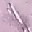

In [7]:
# Display a sample image (optional)
Image(os.path.join(train_dir, train.iloc[0, 0]), width=250, height=250)




In [8]:
def prepare_data(df, m, direc):
    print("preparing data")
    X = np.zeros((m, 150, 150, 3), dtype=np.float32)
    for idx, fname in enumerate(df["id"]):
        img_path = os.path.join(direc, fname)
        img = image.load_img(img_path, target_size=(150, 150))
        x = image.img_to_array(img)
        x = preprocess_input(x) / 255.0
        X[idx] = x
    print("Done")
    return X




In [9]:
# Build training / validation arrays
data = prepare_data(train, train.shape[0], train_dir)
test_data = prepare_data(df_test, len(df_test), test_dir)

X_train = data[:15001]
y_train = train["has_cactus"][:15001].values
X_valid = data[15001:]
y_valid = train["has_cactus"][15001:].values



preparing data
Done
preparing data
Done


In [10]:
# Model definition – same architecture as original
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation="relu", input_shape=(150, 150, 3)))
model.add(layers.MaxPool2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation="relu"))
model.add(layers.MaxPool2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation="relu"))
model.add(layers.MaxPool2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation="relu"))
model.add(layers.MaxPool2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation="relu"))
model.add(layers.MaxPool2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation="relu"))
model.add(layers.Dense(1, activation="sigmoid"))



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-04 18:00:43.357429: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1777917643.357895      55 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:c6:00.0, compute capability: 8.6


In [11]:
model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 651,585 (2.49 MB)

 Trainable params: 651,585 (2.49 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Compile with correct optimizer and metric name
model.compile(
    loss="binary_crossentropy", optimizer=optimizers.RMSprop(), metrics=["accuracy"]
)



In [13]:
epochs = 10
history = model.fit(
    X_train, y_train, epochs=epochs, validation_data=(X_valid, y_valid), verbose=2
)



Epoch 1/10


I0000 00:00:1777917651.628172     112 service.cc:148] XLA service 0x7ff26800b030 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777917651.628214     112 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-05-04 18:00:51.655303: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777917651.776019     112 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1777917653.277309     112 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


443/443 - 8s - 17ms/step - accuracy: 0.9194 - loss: 0.2106
Epoch 2/10


2026-05-04 18:00:58.425821: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-05-04 18:00:58.425883: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]
2026-05-04 18:00:58.425896: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 13359687563191265825
2026-05-04 18:00:58.425908: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 14636657472814811058
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building you

443/443 - 4s - 8ms/step - accuracy: 0.9632 - loss: 0.0987
Epoch 3/10


...

2026-05-04 18:01:24.102910: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]
2026-05-04 18:01:24.103167: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 13359687563191265825
2026-05-04 18:01:24.103182: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 14636657472814811058


443/443 - 4s - 8ms/step - accuracy: 0.9940 - loss: 0.0205
Epoch 10/10


2026-05-04 18:01:27.862933: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 13359687563191265825
2026-05-04 18:01:27.863006: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 14636657472814811058


443/443 - 4s - 8ms/step - accuracy: 0.9943 - loss: 0.0208


2026-05-04 18:01:31.472993: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 13359687563191265825
2026-05-04 18:01:31.473055: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 14636657472814811058


In [14]:
# Plot training & validation accuracy
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
epochs_range = range(1, epochs + 1)
plt.plot(epochs_range, acc, label="training accuracy")
plt.plot(epochs_range, val_acc, label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()



KeyError: 'val_accuracy'

In [15]:
# Plot training & validation loss
loss = history.history["loss"]
val_loss = history.history["val_loss"]
plt.plot(epochs_range, loss, label="training loss")
plt.plot(epochs_range, val_loss, label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()



KeyError: 'val_loss'

In [16]:
# Predict probabilities for test set
y_pred = model.predict(test_data).flatten()



104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [17]:
# Create submission file with required column names
submission = pd.DataFrame({"id": df_test["id"], "has_cactus": y_pred})
submission.to_csv("submission.csv", index=False)
print("Submission saved to submission.csv")

Submission saved to submission.csv
